# 第二十三章：GPT-3 — 語言模型是少樣本學習者
# PyTorch 實作

本 notebook 實作 GPT-3 的核心概念，包括：
1. GPT 風格的 Transformer 解碼器架構
2. 自迴歸語言建模
3. 上下文學習（In-Context Learning）的演示
4. 文本生成策略

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, List
import math

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用裝置: {device}')

使用裝置: cpu


## 1. GPT 模型架構

GPT-3 使用標準的 Transformer 解碼器架構，主要包括：
- 多頭因果自注意力
- 位置前饋網路
- 層正規化（Pre-LayerNorm 配置）

In [2]:
class GELU(nn.Module):
    """
    GELU 活化函數
    GPT-3 使用 GELU 而非 ReLU
    """
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return 0.5 * x * (1.0 + torch.tanh(
            math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3.0))
        ))


class CausalSelfAttention(nn.Module):
    """
    因果自注意力層
    每個位置只能關注自己和之前的位置
    """
    
    def __init__(self, d_model: int, n_heads: int, max_seq_len: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.d_model = d_model
        
        # Q, K, V 投影（合併為一個線性層以提高效率）
        self.c_attn = nn.Linear(d_model, 3 * d_model)
        # 輸出投影
        self.c_proj = nn.Linear(d_model, d_model)
        
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        
        # 因果遮罩：下三角矩陣
        self.register_buffer(
            'mask',
            torch.tril(torch.ones(max_seq_len, max_seq_len)).view(1, 1, max_seq_len, max_seq_len)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape  # batch, sequence length, d_model
        
        # 計算 Q, K, V
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.d_model, dim=2)
        
        # 重塑為多頭格式: (B, n_heads, T, d_head)
        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        
        # 計算注意力分數
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(self.d_head))
        
        # 應用因果遮罩
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
        
        # Softmax 和 dropout
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        
        # 應用注意力到值
        y = att @ v  # (B, n_heads, T, d_head)
        
        # 重塑並投影
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        
        return y


print('因果自注意力層定義完成')

因果自注意力層定義完成


In [3]:
class FeedForward(nn.Module):
    """
    位置前饋網路
    GPT-3 使用 4 倍擴展比例
    """
    
    def __init__(self, d_model: int, d_ff: int = None, dropout: float = 0.1):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        
        self.c_fc = nn.Linear(d_model, d_ff)
        self.c_proj = nn.Linear(d_ff, d_model)
        self.gelu = GELU()
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class TransformerBlock(nn.Module):
    """
    Transformer 解碼器區塊
    使用 Pre-LayerNorm 配置
    """
    
    def __init__(self, d_model: int, n_heads: int, max_seq_len: int, dropout: float = 0.1):
        super().__init__()
        
        self.ln_1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, max_seq_len, dropout)
        self.ln_2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, dropout=dropout)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Pre-LayerNorm 配置
        x = x + self.attn(self.ln_1(x))
        x = x + self.ffn(self.ln_2(x))
        return x


print('Transformer 區塊定義完成')

Transformer 區塊定義完成


In [4]:
class GPT(nn.Module):
    """
    GPT 語言模型
    簡化版的 GPT-3 架構
    """
    
    def __init__(self,
                 vocab_size: int,
                 max_seq_len: int = 1024,
                 d_model: int = 768,
                 n_heads: int = 12,
                 n_layers: int = 12,
                 dropout: float = 0.1):
        super().__init__()
        
        self.max_seq_len = max_seq_len
        self.d_model = d_model
        
        # Token 嵌入
        self.wte = nn.Embedding(vocab_size, d_model)
        # 位置嵌入
        self.wpe = nn.Embedding(max_seq_len, d_model)
        
        self.drop = nn.Dropout(dropout)
        
        # Transformer 層
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, max_seq_len, dropout)
            for _ in range(n_layers)
        ])
        
        # 最終層正規化
        self.ln_f = nn.LayerNorm(d_model)
        
        # 語言建模頭（與 token 嵌入共享權重）
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.wte.weight = self.lm_head.weight  # 權重綁定
        
        # 初始化權重
        self.apply(self._init_weights)
        
        # 統計參數量
        n_params = sum(p.numel() for p in self.parameters())
        print(f'GPT 模型參數量: {n_params:,}')
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            torch.nn.init.zeros_(module.bias)
            torch.nn.init.ones_(module.weight)
    
    def forward(self, idx: torch.Tensor, targets: Optional[torch.Tensor] = None):
        """
        前向傳播
        
        參數:
            idx: token 索引 [batch_size, seq_len]
            targets: 目標 token（用於計算損失）
        
        回傳:
            logits: 預測的 logits
            loss: 交叉熵損失（如果提供 targets）
        """
        B, T = idx.shape
        assert T <= self.max_seq_len, f'序列長度 {T} 超過最大長度 {self.max_seq_len}'
        
        # 嵌入
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device).unsqueeze(0)
        tok_emb = self.wte(idx)  # [B, T, d_model]
        pos_emb = self.wpe(pos)  # [1, T, d_model]
        x = self.drop(tok_emb + pos_emb)
        
        # Transformer 層
        for block in self.blocks:
            x = block(x)
        
        x = self.ln_f(x)
        logits = self.lm_head(x)
        
        # 計算損失
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1
            )
        
        return logits, loss
    
    @torch.no_grad()
    def generate(self,
                 idx: torch.Tensor,
                 max_new_tokens: int,
                 temperature: float = 1.0,
                 top_k: Optional[int] = None) -> torch.Tensor:
        """
        自迴歸生成文本
        
        參數:
            idx: 起始 token 序列
            max_new_tokens: 要生成的 token 數量
            temperature: 採樣溫度
            top_k: Top-K 採樣
        """
        for _ in range(max_new_tokens):
            # 如果序列太長，截斷
            idx_cond = idx if idx.size(1) <= self.max_seq_len else idx[:, -self.max_seq_len:]
            
            # 前向傳播
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            
            # Top-K 採樣
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            
            # 採樣
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            
            # 附加到序列
            idx = torch.cat((idx, idx_next), dim=1)
        
        return idx


# 測試模型
model = GPT(
    vocab_size=1000,
    max_seq_len=256,
    d_model=256,
    n_heads=4,
    n_layers=4
)

# 測試前向傳播
x = torch.randint(0, 1000, (2, 32))
logits, _ = model(x)
print(f'輸入形狀: {x.shape}')
print(f'輸出形狀: {logits.shape}')

GPT 模型參數量: 3,481,088
輸入形狀: torch.Size([2, 32])
輸出形狀: torch.Size([2, 32, 1000])


## 2. GPT-3 規模配置

展示 GPT-3 各個變體的參數配置

In [5]:
# GPT-3 模型配置
GPT3_CONFIGS = {
    'GPT-3 Small': {'n_layers': 12, 'd_model': 768, 'n_heads': 12},
    'GPT-3 Medium': {'n_layers': 24, 'd_model': 1024, 'n_heads': 16},
    'GPT-3 Large': {'n_layers': 24, 'd_model': 1536, 'n_heads': 16},
    'GPT-3 XL': {'n_layers': 24, 'd_model': 2048, 'n_heads': 24},
    'GPT-3 2.7B': {'n_layers': 32, 'd_model': 2560, 'n_heads': 32},
    'GPT-3 6.7B': {'n_layers': 32, 'd_model': 4096, 'n_heads': 32},
    'GPT-3 13B': {'n_layers': 40, 'd_model': 5140, 'n_heads': 40},
    'GPT-3 175B': {'n_layers': 96, 'd_model': 12288, 'n_heads': 96},
}

def count_gpt_params(n_layers: int, d_model: int, n_heads: int, 
                     vocab_size: int = 50257, max_seq_len: int = 2048) -> int:
    """
    計算 GPT 模型的參數量
    """
    # 嵌入參數
    embedding_params = vocab_size * d_model + max_seq_len * d_model
    
    # 每層參數
    d_ff = 4 * d_model
    # 注意力層: Q, K, V 投影 + 輸出投影
    attention_params = 4 * d_model * d_model
    # FFN: 兩個線性層
    ffn_params = 2 * d_model * d_ff
    # LayerNorm: 2 個，每個有 2 * d_model 參數
    ln_params = 4 * d_model
    
    layer_params = attention_params + ffn_params + ln_params
    total_layer_params = n_layers * layer_params
    
    # 最終 LayerNorm
    final_ln = 2 * d_model
    
    # LM head（與嵌入共享權重，不計入）
    
    total = embedding_params + total_layer_params + final_ln
    return total


print('GPT-3 模型配置與參數量')
print('=' * 60)
for name, config in GPT3_CONFIGS.items():
    params = count_gpt_params(**config)
    print(f'{name:15s}: {params/1e9:8.2f}B 參數 '
          f'(layers={config["n_layers"]:2d}, d={config["d_model"]:5d})')

GPT-3 模型配置與參數量
GPT-3 Small    :     0.13B 參數 (layers=12, d=  768)
GPT-3 Medium   :     0.36B 參數 (layers=24, d= 1024)
GPT-3 Large    :     0.76B 參數 (layers=24, d= 1536)
GPT-3 XL       :     1.32B 參數 (layers=24, d= 2048)
GPT-3 2.7B     :     2.65B 參數 (layers=32, d= 2560)
GPT-3 6.7B     :     6.66B 參數 (layers=32, d= 4096)
GPT-3 13B      :    12.95B 參數 (layers=40, d= 5140)
GPT-3 175B     :   174.59B 參數 (layers=96, d=12288)


## 3. 上下文學習演示

展示 GPT 的上下文學習能力（使用簡化的模擬）

In [6]:
class SimpleTokenizer:
    """
    簡單的字元級 tokenizer
    用於演示目的
    """
    
    def __init__(self, text: str):
        chars = sorted(list(set(text)))
        self.char_to_idx = {c: i for i, c in enumerate(chars)}
        self.idx_to_char = {i: c for i, c in enumerate(chars)}
        self.vocab_size = len(chars)
    
    def encode(self, text: str) -> List[int]:
        return [self.char_to_idx.get(c, 0) for c in text]
    
    def decode(self, tokens: List[int]) -> str:
        return ''.join([self.idx_to_char.get(t, '') for t in tokens])


# 創建一個簡單的翻譯資料集來演示上下文學習
translation_examples = """
英文: hello 中文: 你好
英文: world 中文: 世界
英文: apple 中文: 蘋果
英文: book 中文: 書
英文: computer 中文: 電腦
英文: water 中文: 水
英文: sun 中文: 太陽
英文: moon 中文: 月亮
"""

print('上下文學習示例（翻譯任務）：')
print('=' * 50)
print(translation_examples)

上下文學習示例（翻譯任務）：

英文: hello 中文: 你好
英文: world 中文: 世界
英文: apple 中文: 蘋果
英文: book 中文: 書
英文: computer 中文: 電腦
英文: water 中文: 水
英文: sun 中文: 太陽
英文: moon 中文: 月亮



In [7]:
def demonstrate_few_shot_prompt(n_examples: int = 3) -> str:
    """
    生成少樣本提示範例
    """
    examples = [
        ("sea otter", "loutre de mer"),
        ("cheese", "fromage"),
        ("plush giraffe", "girafe en peluche"),
        ("hello", "bonjour"),
        ("goodbye", "au revoir"),
    ]
    
    prompt = "Translate English to French:\n\n"
    
    for eng, fra in examples[:n_examples]:
        prompt += f"{eng} => {fra}\n"
    
    prompt += "computer =>"
    
    return prompt


print('零樣本提示（Zero-Shot）：')
print('-' * 40)
print("Translate English to French:\ncomputer =>")
print()

print('單樣本提示（One-Shot）：')
print('-' * 40)
print(demonstrate_few_shot_prompt(1))
print()

print('少樣本提示（Few-Shot）：')
print('-' * 40)
print(demonstrate_few_shot_prompt(4))

零樣本提示（Zero-Shot）：
----------------------------------------
Translate English to French:
computer =>

單樣本提示（One-Shot）：
----------------------------------------
Translate English to French:

sea otter => loutre de mer
computer =>

少樣本提示（Few-Shot）：
----------------------------------------
Translate English to French:

sea otter => loutre de mer
cheese => fromage
plush giraffe => girafe en peluche
hello => bonjour
computer =>


## 4. 訓練一個小型 GPT 模型

使用合成資料訓練一個小型 GPT 模型

In [8]:
# 準備訓練資料：簡單的字元序列
training_text = """
The quick brown fox jumps over the lazy dog.
A journey of a thousand miles begins with a single step.
To be or not to be, that is the question.
All that glitters is not gold.
Actions speak louder than words.
Knowledge is power.
Time flies like an arrow.
Practice makes perfect.
Where there is a will, there is a way.
Every cloud has a silver lining.
""" * 50  # 重複以增加資料量

# 創建 tokenizer
tokenizer = SimpleTokenizer(training_text)
print(f'詞彙表大小: {tokenizer.vocab_size}')

# 編碼文本
data = torch.tensor(tokenizer.encode(training_text), dtype=torch.long)
print(f'資料長度: {len(data)} tokens')

# 創建訓練資料集
def get_batch(data: torch.Tensor, batch_size: int, seq_len: int):
    """獲取一個訓練批次"""
    ix = torch.randint(len(data) - seq_len - 1, (batch_size,))
    x = torch.stack([data[i:i+seq_len] for i in ix])
    y = torch.stack([data[i+1:i+seq_len+1] for i in ix])
    return x.to(device), y.to(device)

詞彙表大小: 36
資料長度: 17550 tokens


In [9]:
# 創建小型 GPT 模型
small_gpt = GPT(
    vocab_size=tokenizer.vocab_size,
    max_seq_len=128,
    d_model=128,
    n_heads=4,
    n_layers=4,
    dropout=0.1
).to(device)

# 訓練設定
optimizer = optim.AdamW(small_gpt.parameters(), lr=3e-4)
batch_size = 32
seq_len = 64
n_steps = 1000

# 訓練迴圈
losses = []
print('開始訓練...')

for step in range(n_steps):
    x, y = get_batch(data, batch_size, seq_len)
    
    optimizer.zero_grad()
    logits, loss = small_gpt(x, y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(small_gpt.parameters(), 1.0)
    optimizer.step()
    
    losses.append(loss.item())
    
    if step % 200 == 0:
        print(f'步驟 {step:4d}: 損失 = {loss.item():.4f}')

print(f'\n訓練完成！最終損失: {losses[-1]:.4f}')

GPT 模型參數量: 814,336
開始訓練...
步驟    0: 損失 = 3.6521
步驟  200: 損失 = 0.6882
步驟  400: 損失 = 0.1821
步驟  600: 損失 = 0.1078
步驟  800: 損失 = 0.1002

訓練完成！最終損失: 0.0788


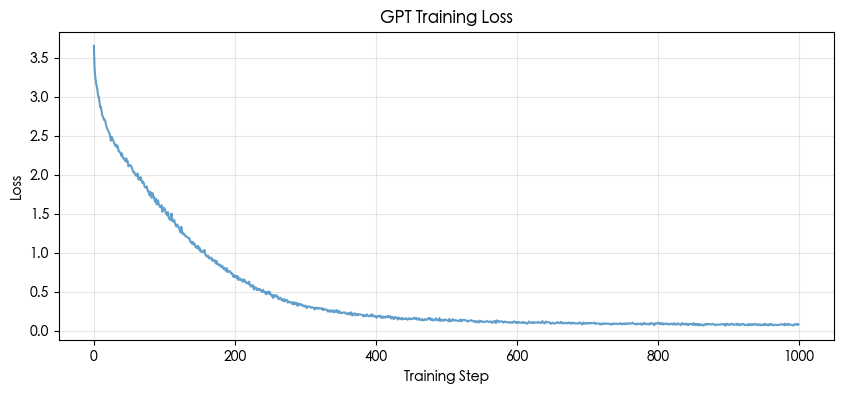

In [10]:
# 繪製訓練曲線
plt.figure(figsize=(10, 4))
plt.plot(losses, alpha=0.7)
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('GPT Training Loss')
plt.grid(True, alpha=0.3)
plt.savefig('gpt_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# 生成文本
small_gpt.eval()

# 起始提示
prompt = "The quick "
prompt_tokens = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long).to(device)

print('文本生成演示：')
print('=' * 50)
print(f'提示: "{prompt}"')
print()

# 不同溫度的生成
for temp in [0.5, 0.8, 1.0, 1.5]:
    generated = small_gpt.generate(prompt_tokens.clone(), max_new_tokens=50, temperature=temp)
    text = tokenizer.decode(generated[0].tolist())
    print(f'溫度 {temp}: {text[:80]}...')

文本生成演示：
提示: "The quick "

溫度 0.5: The quick brown fox jumps over the lazy dog.
A journey of a ...
溫度 0.8: The quick brown fox jumps over the lazy dog.
A journey of a ...
溫度 1.0: The quick brown fox jumps over the lazy dog.
A journey of a ...
溫度 1.5: The quick brown fox jumps over the lazzy dog.
A journey of a...


## 5. 視覺化 GPT-3 的縮放效果

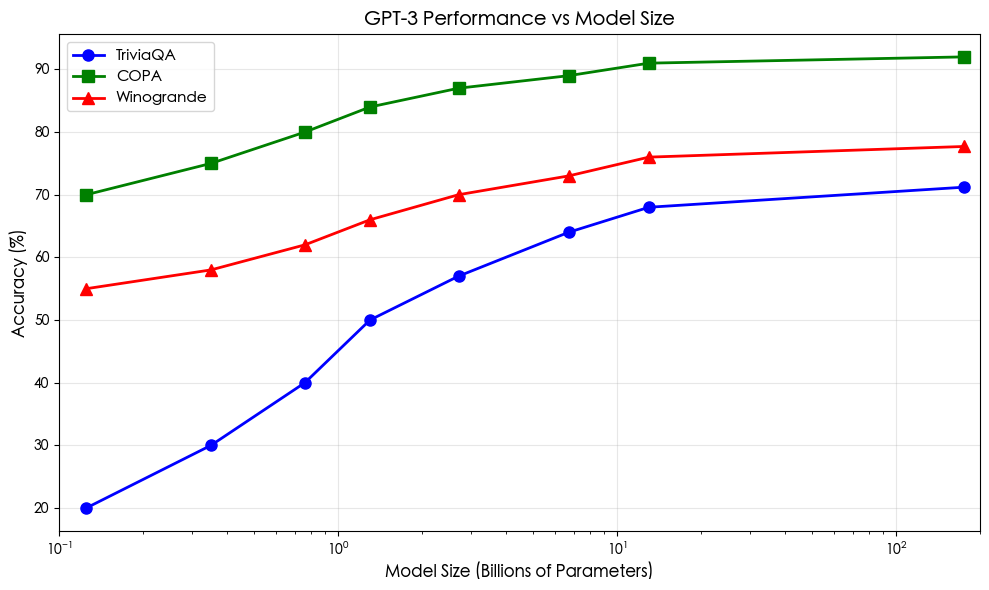

In [12]:
# 模擬 GPT-3 不同規模在各任務上的表現
# 資料來自論文

model_sizes = [0.125, 0.35, 0.76, 1.3, 2.7, 6.7, 13, 175]  # 十億參數

# 模擬的任務準確率
trivia_qa = [20, 30, 40, 50, 57, 64, 68, 71.2]  # TriviaQA
copa = [70, 75, 80, 84, 87, 89, 91, 92]  # COPA
winogrande = [55, 58, 62, 66, 70, 73, 76, 77.7]  # Winogrande

fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogx(model_sizes, trivia_qa, 'bo-', linewidth=2, markersize=8, label='TriviaQA')
ax.semilogx(model_sizes, copa, 'gs-', linewidth=2, markersize=8, label='COPA')
ax.semilogx(model_sizes, winogrande, 'r^-', linewidth=2, markersize=8, label='Winogrande')

ax.set_xlabel('Model Size (Billions of Parameters)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('GPT-3 Performance vs Model Size', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.1, 200])

plt.tight_layout()
plt.savefig('gpt3_scaling_performance.png', dpi=150, bbox_inches='tight')
plt.show()

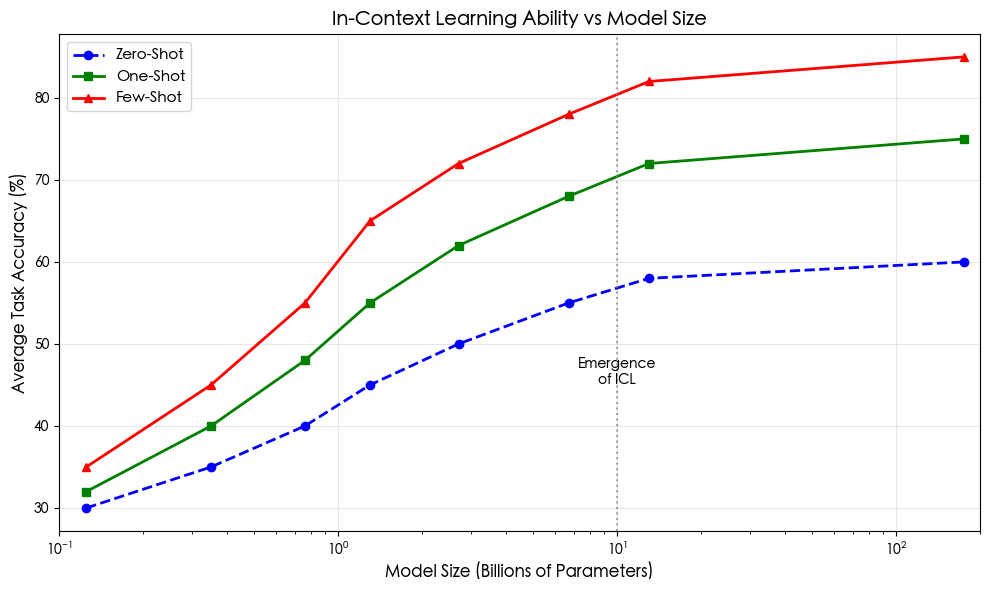

In [13]:
# 上下文學習能力的縮放
# 展示不同規模模型在零樣本、單樣本、少樣本設定下的表現

fig, ax = plt.subplots(figsize=(10, 6))

# 模擬資料（基於論文趨勢）
zero_shot = [30, 35, 40, 45, 50, 55, 58, 60]
one_shot = [32, 40, 48, 55, 62, 68, 72, 75]
few_shot = [35, 45, 55, 65, 72, 78, 82, 85]

ax.semilogx(model_sizes, zero_shot, 'b--', linewidth=2, marker='o', label='Zero-Shot')
ax.semilogx(model_sizes, one_shot, 'g-', linewidth=2, marker='s', label='One-Shot')
ax.semilogx(model_sizes, few_shot, 'r-', linewidth=2, marker='^', label='Few-Shot')

ax.set_xlabel('Model Size (Billions of Parameters)', fontsize=12)
ax.set_ylabel('Average Task Accuracy (%)', fontsize=12)
ax.set_title('In-Context Learning Ability vs Model Size', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.1, 200])

# 標註上下文學習的湧現
ax.axvline(x=10, color='gray', linestyle=':', alpha=0.7)
ax.annotate('Emergence\nof ICL', xy=(10, 45), fontsize=10, ha='center')

plt.tight_layout()
plt.savefig('gpt3_icl_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. GPT-3 算術能力分析

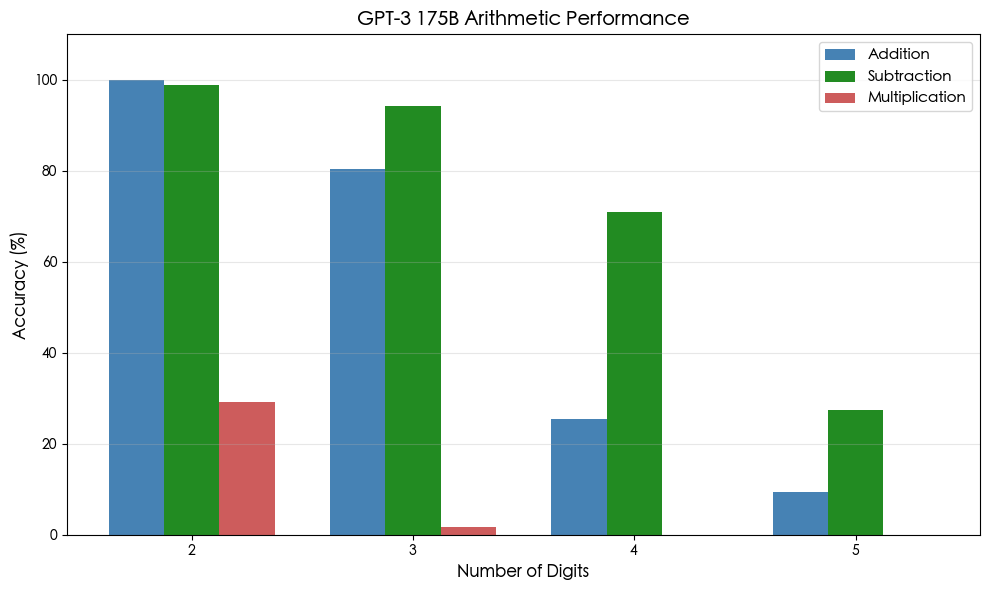

觀察：
- 加法和減法在 2-3 位數時表現良好
- 乘法對 GPT-3 來說非常困難
- 這暗示某些類型的推理需要特殊處理


In [14]:
# GPT-3 175B 在不同算術任務上的表現
digits = [2, 3, 4, 5]
addition_acc = [100, 80.4, 25.5, 9.3]
subtraction_acc = [98.9, 94.2, 71.0, 27.4]
multiplication_acc = [29.2, 1.8, 0.0, 0.0]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(digits))
width = 0.25

bars1 = ax.bar(x - width, addition_acc, width, label='Addition', color='steelblue')
bars2 = ax.bar(x, subtraction_acc, width, label='Subtraction', color='forestgreen')
bars3 = ax.bar(x + width, multiplication_acc, width, label='Multiplication', color='indianred')

ax.set_xlabel('Number of Digits', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('GPT-3 175B Arithmetic Performance', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(digits)
ax.legend(fontsize=11)
ax.set_ylim([0, 110])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('gpt3_arithmetic.png', dpi=150, bbox_inches='tight')
plt.show()

print('觀察：')
print('- 加法和減法在 2-3 位數時表現良好')
print('- 乘法對 GPT-3 來說非常困難')
print('- 這暗示某些類型的推理需要特殊處理')

## 7. 總結

本 notebook 展示了：

1. **GPT 架構的核心組件**：因果自注意力、前饋網路、Pre-LayerNorm
2. **GPT-3 的規模配置**：從 125M 到 175B 參數的不同變體
3. **上下文學習的概念**：零樣本、單樣本、少樣本提示
4. **小型 GPT 的訓練**：語言建模目標和文本生成
5. **縮放效果的視覺化**：性能與模型規模的關係

In [15]:
print('=' * 60)
print('GPT-3: Language Models are Few-Shot Learners')
print('=' * 60)
print()
print('關鍵數據：')
print(f'  - 參數量: 175B')
print(f'  - 層數: 96')
print(f'  - 隱藏維度: 12288')
print(f'  - 注意力頭數: 96')
print(f'  - 上下文長度: 2048 tokens')
print(f'  - 訓練資料: ~570GB')
print()
print('參考文獻：')
print('Brown et al., "Language Models are Few-Shot Learners"')
print('arXiv:2005.14165, NeurIPS 2020')

GPT-3: Language Models are Few-Shot Learners

關鍵數據：
  - 參數量: 175B
  - 層數: 96
  - 隱藏維度: 12288
  - 注意力頭數: 96
  - 上下文長度: 2048 tokens
  - 訓練資料: ~570GB

參考文獻：
Brown et al., "Language Models are Few-Shot Learners"
arXiv:2005.14165, NeurIPS 2020
